## Notebook to explore and tweak visuals for ML results.


In [52]:
import sys
sys.path.append("../src")
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import altair as alt 
import seaborn as sns

from postmodel.get_metrics import get_metrics 

In [2]:
metrics = get_metrics()
df = pd.DataFrame(metrics).T
df

MODEL_DIR: C:\Users\kevin\OneDrive\Desktop\SIADS-Capstone\SafePath\models
Loaded 3 metrics files just now.


,logistic_regression,random_forest,logistic_no_lag,rf_no_lag,lightgbm_with_lag,lightgbm_no_lag
baseline_metrics,"{'roc_auc': 0.9810716867086169, 'average_preci...","{'roc_auc': 0.981686119705926, 'average_precis...",NaN,NaN,NaN,NaN
baseline_no_lag_metrics,NaN,NaN,"{'roc_auc': 0.6581504862312604, 'average_preci...","{'roc_auc': 0.6807534289142305, 'average_preci...",NaN,NaN
lightgbm_metrics,NaN,NaN,NaN,NaN,"{'roc_auc': 0.9822509237625807, 'average_preci...","{'roc_auc': 0.6922006039480029, 'average_preci..."


In [ ]:
rows = []

for model_name, metrics_dict in metrics.items():
    for metric_name, value in metrics_dict.items():
        rows.append({
            "model": model_name,
            "metric": metric_name,
            "value": value
        })

tidy_df = pd.DataFrame(rows)
tidy_df

,model,metric,value
0,baseline_metrics,logistic_regression,"{'roc_auc': 0.9810716867086169, 'average_preci..."
1,baseline_metrics,random_forest,"{'roc_auc': 0.981686119705926, 'average_precis..."
2,baseline_no_lag_metrics,logistic_no_lag,"{'roc_auc': 0.6581504862312604, 'average_preci..."
3,baseline_no_lag_metrics,rf_no_lag,"{'roc_auc': 0.6807534289142305, 'average_preci..."
4,lightgbm_metrics,lightgbm_with_lag,"{'roc_auc': 0.9822509237625807, 'average_preci..."
5,lightgbm_metrics,lightgbm_no_lag,"{'roc_auc': 0.6922006039480029, 'average_preci..."


In [8]:
rows = []

for _, row in tidy_df.iterrows():
    model_family = row["model"]
    model_name = row["metric"]
    metrics_dict = row["value"]

    # Skip NaNs (just in case)
    if isinstance(metrics_dict, dict):
        for metric_name, value in metrics_dict.items():
            rows.append({
                "model_family": model_family,
                "model_name": model_name,
                "metric_name": metric_name,
                "value": value
            })

flat_df = pd.DataFrame(rows)
flat_df


,model_family,model_name,metric_name,value
0,baseline_metrics,logistic_regression,roc_auc,0.981072
1,baseline_metrics,logistic_regression,average_precision,0.98612
2,baseline_metrics,logistic_regression,confusion_matrix,"[[278440, 52], [6528, 188398]]"
3,baseline_metrics,logistic_regression,classification_report,"{'0': {'precision': 0.977092164734286, 'recall..."
4,baseline_metrics,random_forest,roc_auc,0.981686
5,baseline_metrics,random_forest,average_precision,0.986388
6,baseline_metrics,random_forest,confusion_matrix,"[[278490, 2], [6528, 188398]]"
7,baseline_metrics,random_forest,classification_report,"{'0': {'precision': 0.9770961833989432, 'recal..."
8,baseline_no_lag_metrics,logistic_no_lag,roc_auc,0.65815
9,baseline_no_lag_metrics,logistic_no_lag,average_precision,0.599882


In [49]:
# Grabbing the ROC_AUC anv AVG_Precision
scalar_df = flat_df[
    flat_df.metric_name.isin(["roc_auc", "average_precision"])
].copy()

#FAMILY MAP WILL NEED UPDATING IF MORE MODELS ARE ADDED
family_map = {
    "baseline_metrics": "Baseline (Lag)",
    "baseline_no_lag_metrics": "Baseline (No Lag)",
    "lightgbm_metrics": "LightGBM"
}

scalar_df["family_clean"] = scalar_df["model_family"].map(family_map)

scalar_df

,model_family,model_name,metric_name,value,family_clean
0,baseline_metrics,logistic_regression,roc_auc,0.981072,Baseline (Lag)
1,baseline_metrics,logistic_regression,average_precision,0.98612,Baseline (Lag)
4,baseline_metrics,random_forest,roc_auc,0.981686,Baseline (Lag)
5,baseline_metrics,random_forest,average_precision,0.986388,Baseline (Lag)
8,baseline_no_lag_metrics,logistic_no_lag,roc_auc,0.65815,Baseline (No Lag)
9,baseline_no_lag_metrics,logistic_no_lag,average_precision,0.599882,Baseline (No Lag)
12,baseline_no_lag_metrics,rf_no_lag,roc_auc,0.680753,Baseline (No Lag)
13,baseline_no_lag_metrics,rf_no_lag,average_precision,0.616236,Baseline (No Lag)
16,lightgbm_metrics,lightgbm_with_lag,roc_auc,0.982251,LightGBM
17,lightgbm_metrics,lightgbm_with_lag,average_precision,0.986636,LightGBM


## ROC_AUC curves and comparisons

In [19]:
roc_df = scalar_df[scalar_df.metric_name == "roc_auc"].copy()
roc_df = roc_df.sort_values("value", ascending=False)


roc_chart = (
    alt.Chart(roc_df)
    .mark_bar()
    .encode(
        x=alt.X("model_name:N", sort=roc_df["model_name"].tolist(), title="Model"),
        y=alt.Y("value:Q", title="ROC-AUC"),
        color=alt.Color("family_clean:N", title="Model Family"),
        tooltip=["model_name", "family_clean", "value"]
    )
    .properties(
        width=550,
        height=320,
        title="ROC-AUC Comparison Across Models"
    )
)


roc_chart


alt.Chart(...)

## Heatmap

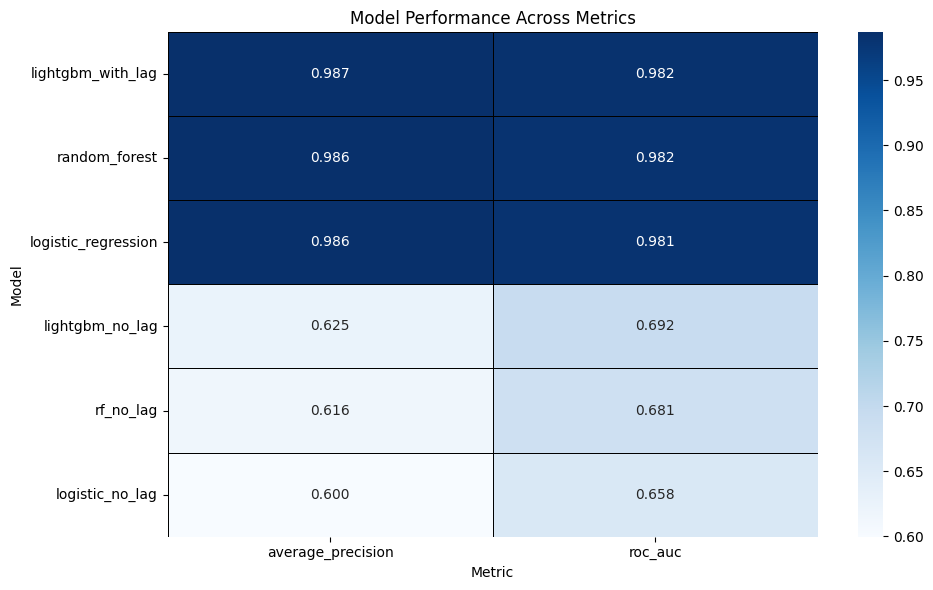

In [22]:
order = roc_df["model_name"].tolist()

heatmap_df = scalar_df.pivot(
    index="model_name",
    columns="metric_name",
    values="value"
).loc[order]

#grab numerics
heatmap_df = heatmap_df.apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_df, annot=True, cmap="Blues", fmt=".3f",linewidths=0.5,linecolor="black")
plt.title("Model Performance Across Metrics")
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()



## Confusion Matrix

In [59]:
# Helper function
def plot_confusion_matrix(cm, title, normalize=False, annot_style="decimal"):
    """
    annot_style options:
    - "decimal": show 4 decimal places (0.0002, 0.9998)
    - "threshold": show <0.01 or >0.99 for extreme values
    """

    cm = np.array(cm)

    if normalize:
        cm = cm / cm.sum(axis=1, keepdims=True)

    annot = []
    for row in cm:
        formatted_row = []
        for val in row:

            if not normalize:
                # Default 
                formatted_row.append(f"{int(val)}")
                continue

            # Normalized annotation styles
            if annot_style == "decimal":
                formatted_row.append(f"{val:.4f}")

            elif annot_style == "threshold":
                if val < 0.01:
                    formatted_row.append("<0.01")
                elif val > 0.99:
                    formatted_row.append(">0.99")
                else:
                    formatted_row.append(f"{val:.2f}")

        annot.append(formatted_row)


    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred: No Crash", "Pred: Crash"],
        yticklabels=["Actual: No Crash", "Actual: Crash"],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")


In [60]:
# Isolating the data
cm_df = flat_df[flat_df.metric_name == "confusion_matrix"]

confusion_matrices = {
    row.model_name: row.value
    for _, row in cm_df.iterrows()
}

confusion_matrices


{'logistic_regression': [[278440, 52], [6528, 188398]],
 'random_forest': [[278490, 2], [6528, 188398]],
 'logistic_no_lag': [[212739, 65753], [102310, 92616]],
 'rf_no_lag': [[194887, 83605], [83743, 111183]],
 'lightgbm_with_lag': [[278491, 1], [6528, 188398]],
 'lightgbm_no_lag': [[179513, 98979], [70797, 124129]]}

In [51]:
# Group models by lag/no-lag
lag_models = {k: v for k, v in confusion_matrices.items() if "no_lag" not in k}
no_lag_models = {k: v for k, v in confusion_matrices.items() if "no_lag" in k}

# Sort keys 
lag_models = dict(sorted(lag_models.items()))
no_lag_models = dict(sorted(no_lag_models.items()))


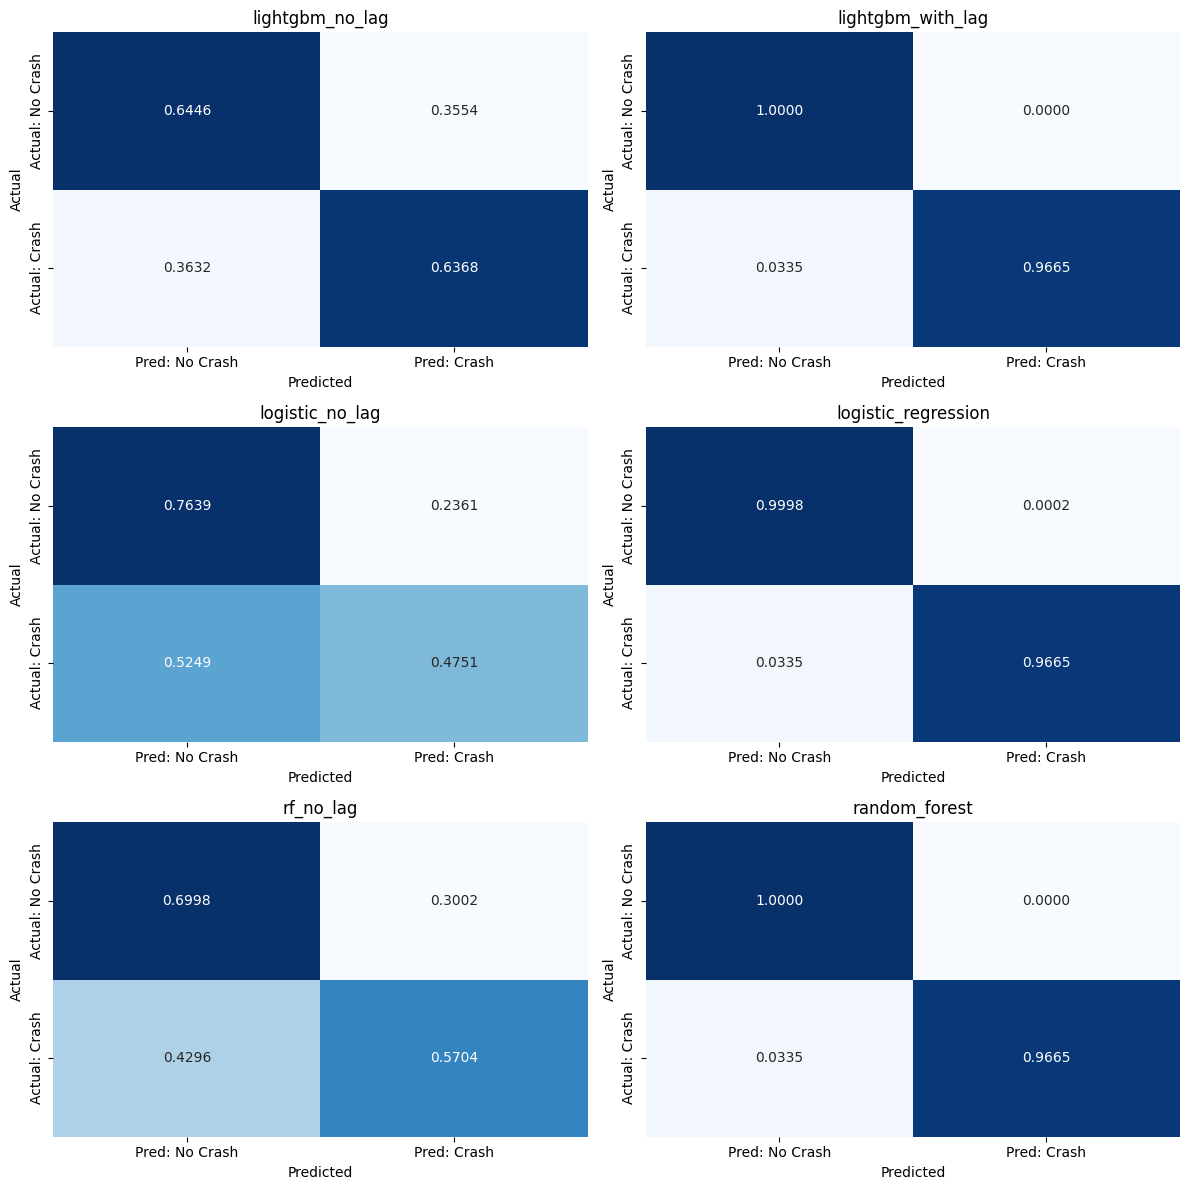

In [58]:
model_pairs = list(zip(no_lag_models.items(), lag_models.items()))
n = len(model_pairs)

plt.figure(figsize=(12, 4 * n))

for i, ((name_no_lag, cm_no_lag), (name_lag, cm_lag)) in enumerate(model_pairs):
    row = i * 2
    
    # No-lag subplot
    plt.subplot(n, 2, row + 1)
    plot_confusion_matrix(cm_no_lag, f"{name_no_lag}", normalize=True, annot_style="decimal")
    
    # Lag subplot
    plt.subplot(n, 2, row + 2)
    plot_confusion_matrix(cm_lag, f"{name_lag}", normalize=True, annot_style="decimal")

plt.tight_layout()
plt.show()



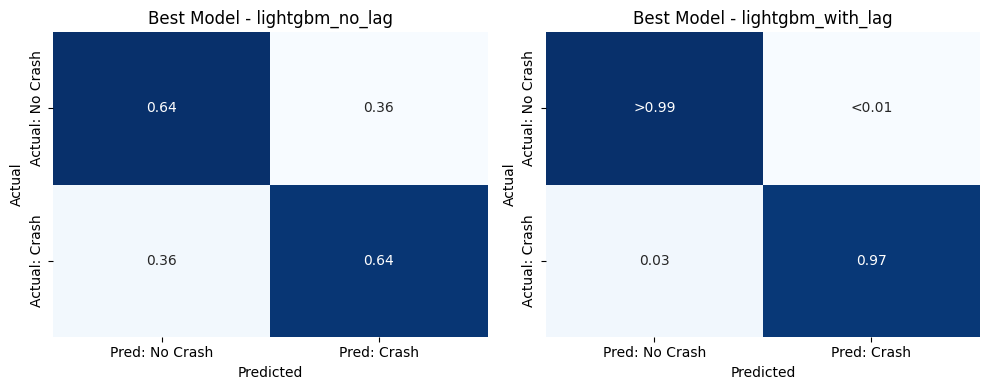

In [ ]:
#Isolate the best performer
best_model_lag = "lightgbm_with_lag"
best_model_no_lag = "lightgbm_no_lag"

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_confusion_matrix(confusion_matrices[best_model_no_lag],
                      f"Best Model - {best_model_no_lag}", normalize=True, annot_style="threshold")

plt.subplot(1, 2, 2)
plot_confusion_matrix(confusion_matrices[best_model_lag],
                      f"Best Model - {best_model_lag}", normalize=True, annot_style="threshold")

plt.tight_layout()
plt.show()
